ReAct Agent


In [173]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [174]:
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")


## Tools For LLM


### DuckDuckGo Search Tool


In [175]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)


#### Arxiv Query Tool


In [176]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

Wikipedia Search Tool


In [177]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

Custom Tool


In [178]:
@tool
def calculator(query: str) -> str:

    """This tool allows you to perform calculations using Python's eval function."""
    try:
        result = eval(query)
        return str(result)
    except Exception as e:
        return f"Error in calculation: {e}"

## TOOL BINDING


In [179]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, calculator]
llm_with_tools = llm.bind_tools(tools)

llm_with_tools.invoke("What is the latest news on AI research?").tool_calls

[{'name': 'search_duckduckgo',
  'args': {'query': 'AI research'},
  'id': 'f5316568-19b5-4206-863b-c2fc3b326855',
  'type': 'tool_call'}]

## Graph_State


In [180]:
from typing import List, Annotated, TypedDict
from operator import add 

class Graph_State(TypedDict):
    messages : Annotated[List, add]

## Create Node Function


In [181]:
def llm_node(state : Graph_State) -> Graph_State:

    messages = state['messages']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that can use tools to answer questions."),
        ("human", "{input}")
    ])

    chain = prompt | llm_with_tools

    response = chain.invoke({"input" : messages})
    print(messages)

    # response_ai = AIMessage(content=response)
    state['messages'] = [response]

    return state

## Create the Tool Node


In [182]:
def tool_node(state : Graph_State) -> Graph_State:

    messages = state['messages']
    
    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool in messages[-1].tool_calls:

        # t = tools_by_name.get(tool.name)
                    ## or
        t = tools_by_name[tool["name"]]

        observation = t.invoke(tool["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool["id"]))

    state["messages"] = tool_results

    return state 






Creating Conditional Edge Function

In [183]:
def if_tool_call(state : Graph_State):
    messages = state['messages']

    if messages[-1].tool_calls:
        return "tool_node"
    else:
        return "end"

Create the Graph Diagram


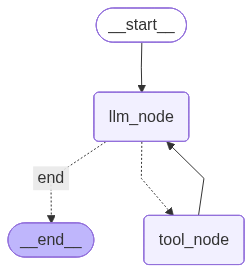

In [184]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(Graph_State)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node" : "tool_node", "end" : END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

## Graph Invoke

In [185]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

[HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={})]
[HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news on AI"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cb315-1b28-7351-87b5-1c4d4bcc44fd-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': '3c6da203-17f7-460f-a634-9408105729a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 125, 'output_tokens': 10, 'total_tokens': 135, 'input_token_details': {'cache_read': 0}}), ToolMessage(content="6 Feb 2026·... AI video tools like Grok Imagine and Kling 3.0 are getting better and better. We also get into the latest AI drama and rapid-fire launches. 

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news on AI"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cb315-1b28-7351-87b5-1c4d4bcc44fd-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': '3c6da203-17f7-460f-a634-9408105729a1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 125, 'output_tokens': 10, 'total_tokens': 135, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content="6 Feb 2026·... AI video tools like Grok Imagine and Kling 3.0 are getting better and better. We also get into the latest AI drama and rapid-fire launches. #ainews #ai ... 26 Nov 2025·Goldman Sachs and Deutsche Bank test agentic AI for trad